# South East HLLRD event report from the merge point

This notebook runs the HLLRD pipeline on the real South East arrival cluster, but it first trims each trajectory to start at the South East merge point where approach control is expected to matter. The computation launcher is included in the notebook so the matrix, model, tables, and figures can be regenerated in one run.

In [37]:
from __future__ import annotations

from dataclasses import asdict
import json
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'hllrd').exists():
            return candidate
    raise RuntimeError('Could not find the project root from the current notebook working directory.')


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hllrd.data import cluster_metadata_by_flight, filter_tracks_to_cluster, load_cluster_flights, trim_tracks_from_anchor
from hllrd.fit import HLLRDV1Config, event_summary, fit_localized_low_rank, load_fit_result, save_fit_result
from hllrd.geometry import LocalProjection, cumulative_distance_m
from hllrd.matrix import MatrixBuildConfig, build_matrix_from_tracks, load_matrix_artifact, save_matrix_artifact
from hllrd.report import write_event_summary_csv, write_model_summary_json
from scenario.trajectory_compressor.io import load_raw_adsb, split_tracks_by_gap

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

PROJECT_ROOT

PosixPath('/Volumes/CrucialX/project-rustlingtree')

## Run configuration

The supplied merge point is approximate. The trim step refines it by finding each SE flight's closest sample to the coarse point and taking the median of nearby closest samples. The matrix is then built only from each flight's closest merge-point sample through the end of the track.

In [38]:
CLUSTER = 'SE'
RAW_ADSB_DIR = PROJECT_ROOT / 'data' / 'adsb' / 'raw'
CLUSTER_ARTIFACTS = PROJECT_ROOT / 'data' / 'artifacts' / 'simap_arrival_flights.jsonl'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'hllrd' / 'south-east'

COARSE_MERGE_ANCHOR_LON_DEG = -96.25
COARSE_MERGE_ANCHOR_LAT_DEG = 32.25
MAX_ANCHOR_DISTANCE_NM = 15.0
ANCHOR_REFINEMENT_RADIUS_NM = 25.0

STATIONS = 200
MIN_POINTS_PER_FLIGHT = 3
SPLIT_GAP_SECONDS = 25 * 60
PROCESS_COUNT = 1
REBUILD = False

FIT_CONFIG = HLLRDV1Config(
    L_min=40,
    K_max=6,
    kappa_peak=2.0,
    smoothing_window=5,
    epsilon_gain=0.001,
)

matrix_path = OUTPUT_DIR / f'matrix_{CLUSTER}_from_merge.npz'
model_path = OUTPUT_DIR / 'model_from_merge_L40_K6.npz'
summary_path = OUTPUT_DIR / 'summary_from_merge_L40_K6.json'
events_csv_path = OUTPUT_DIR / 'events_from_merge_L40_K6.csv'
trim_metadata_path = OUTPUT_DIR / 'trim_from_merge_metadata.csv'

config_table = pd.DataFrame(
    [
        ('cluster', CLUSTER),
        ('coarse_merge_anchor_lon_lat', f'{COARSE_MERGE_ANCHOR_LON_DEG:.4f}, {COARSE_MERGE_ANCHOR_LAT_DEG:.4f}'),
        ('max_anchor_distance_nm', MAX_ANCHOR_DISTANCE_NM),
        ('raw_adsb_dir', RAW_ADSB_DIR.as_posix()),
        ('cluster_artifacts', CLUSTER_ARTIFACTS.as_posix()),
        ('output_dir', OUTPUT_DIR.as_posix()),
        ('stations', STATIONS),
        ('L_min', FIT_CONFIG.L_min),
        ('K_max', FIT_CONFIG.K_max),
        ('activation_scale', FIT_CONFIG.activation_scale),
        ('rebuild', REBUILD),
    ],
    columns=['setting', 'value'],
)
display(config_table)

,setting,value
0,cluster,SE
1,coarse_merge_anchor_lon_lat,"-96.2500, 32.2500"
2,max_anchor_distance_nm,15.0
3,raw_adsb_dir,/Volumes/CrucialX/project-rustlingtree/data/ad...
4,cluster_artifacts,/Volumes/CrucialX/project-rustlingtree/data/ar...
5,output_dir,/Volumes/CrucialX/project-rustlingtree/data/hl...
6,stations,200
7,L_min,40
8,K_max,6
9,activation_scale,1.0


## Launch computation

This cell is the notebook-local pipeline launcher. It reads the South East flight list, loads and splits raw ADS-B tracks, trims each track from the refined merge anchor to the track end, builds the aligned normal-residual matrix, fits HLLRD, and writes reusable artifacts.

In [39]:
def build_or_load_south_east_from_merge() -> tuple[object, object, list[object], pd.DataFrame]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    flights = load_cluster_flights(CLUSTER_ARTIFACTS, CLUSTER)
    if not flights:
        raise RuntimeError(f'No {CLUSTER} flights found in {CLUSTER_ARTIFACTS}')

    needs_matrix = REBUILD or not matrix_path.exists() or not trim_metadata_path.exists()
    needs_model = REBUILD or needs_matrix or not model_path.exists()
    if not needs_model:
        with np.load(model_path, allow_pickle=False) as data:
            config_payload = json.loads(str(np.asarray(data['config']).item()))
            metrics_payload = json.loads(str(np.asarray(data['metrics']).item()))
        if 'tau_z' in config_payload or 'activation_energy_floor' not in metrics_payload:
            needs_model = True
            print('Existing model artifact uses the old activation threshold; rebuilding model.')

    if needs_matrix:
        print(f'Loading raw ADS-B from {RAW_ADSB_DIR} ...')
        tracks = load_raw_adsb(RAW_ADSB_DIR, PROCESS_COUNT)
        tracks = split_tracks_by_gap(tracks, SPLIT_GAP_SECONDS)
        tracks = filter_tracks_to_cluster(tracks, flights)
        if tracks.empty:
            raise RuntimeError(f'No raw ADS-B rows matched {len(flights)} {CLUSTER} cluster flights')

        trim = trim_tracks_from_anchor(
            tracks,
            anchor_lat_deg=COARSE_MERGE_ANCHOR_LAT_DEG,
            anchor_lon_deg=COARSE_MERGE_ANCHOR_LON_DEG,
            max_anchor_distance_nm=MAX_ANCHOR_DISTANCE_NM,
            min_points_after_anchor=MIN_POINTS_PER_FLIGHT,
            refinement_radius_nm=ANCHOR_REFINEMENT_RADIUS_NM,
        )
        trimmed_tracks = trim.tracks
        trim_metadata = trim.metadata
        trim_metadata.to_csv(trim_metadata_path, index=False)
        if trimmed_tracks.empty:
            raise RuntimeError('All tracks were dropped by the merge-anchor trim.')

        matrix_config = MatrixBuildConfig(
            station_count=STATIONS,
            min_points_per_flight=MIN_POINTS_PER_FLIGHT,
            center_method='median',
        )
        kept = trim_metadata.loc[trim_metadata['status'] == 'kept']
        matrix = build_matrix_from_tracks(
            trimmed_tracks,
            config=matrix_config,
            cluster=CLUSTER,
            metadata={
                'raw_adsb_dir': RAW_ADSB_DIR.as_posix(),
                'cluster_artifacts': CLUSTER_ARTIFACTS.as_posix(),
                'cluster_flight_count': len(flights),
                'trim': {
                    'coarse_anchor_lat_deg': COARSE_MERGE_ANCHOR_LAT_DEG,
                    'coarse_anchor_lon_deg': COARSE_MERGE_ANCHOR_LON_DEG,
                    'refined_anchor_lat_deg': trim.refined_anchor_lat_deg,
                    'refined_anchor_lon_deg': trim.refined_anchor_lon_deg,
                    'max_anchor_distance_nm': MAX_ANCHOR_DISTANCE_NM,
                    'kept_flight_count': int(len(kept)),
                    'dropped_flight_count': int(len(trim.dropped_flights)),
                    'median_anchor_distance_nm': float(kept['min_anchor_distance_nm'].median()),
                    'max_anchor_distance_observed_nm': float(kept['min_anchor_distance_nm'].max()),
                },
            },
        )
        save_matrix_artifact(matrix_path, matrix)
        print(f'Wrote merge-trimmed matrix artifact: {matrix_path}')
    else:
        matrix = load_matrix_artifact(matrix_path)
        trim_metadata = pd.read_csv(trim_metadata_path)
        print(f'Loaded merge-trimmed matrix artifact: {matrix_path}')

    if needs_model:
        result = fit_localized_low_rank(
            matrix.X,
            FIT_CONFIG,
            already_centered=False,
            metadata={
                'matrix': matrix_path.as_posix(),
                'cluster': matrix.cluster,
                'flight_count': len(matrix.flight_ids),
                'config': asdict(FIT_CONFIG),
            },
        )
        save_fit_result(model_path, result, flight_ids=matrix.flight_ids)
        write_model_summary_json(summary_path, result)
        write_event_summary_csv(events_csv_path, result)
        print(f'Wrote merge-trimmed model artifact: {model_path}')
    else:
        result = load_fit_result(model_path)
        print(f'Loaded merge-trimmed model artifact: {model_path}')

    return matrix, result, flights, trim_metadata


matrix, result, cluster_flights, trim_metadata = build_or_load_south_east_from_merge()
flight_metadata = cluster_metadata_by_flight(cluster_flights)
kept_trim = trim_metadata.loc[trim_metadata['status'] == 'kept'].copy()
trim_info = matrix.metadata.get('trim', {})

run_summary = pd.DataFrame(
    [
        ('cluster flights in artifact', len(cluster_flights)),
        ('matrix flights after trim', len(matrix.flight_ids)),
        ('dropped by trim', int((trim_metadata['status'] == 'dropped').sum())),
        ('refined anchor lon, lat', f"{trim_info.get('refined_anchor_lon_deg', np.nan):.5f}, {trim_info.get('refined_anchor_lat_deg', np.nan):.5f}"),
        ('median anchor distance nm', float(kept_trim['min_anchor_distance_nm'].median())),
        ('max anchor distance nm', float(kept_trim['min_anchor_distance_nm'].max())),
        ('stations', matrix.X.shape[1]),
        ('sigma_hat_m', matrix.sigma_hat),
        ('activation_rms_floor_m', np.sqrt(result.activation_energy_floor)),
        ('events', len(result.events)),
        ('explained_fraction', result.explained_fraction),
    ],
    columns=['metric', 'value'],
)
display(run_summary)
display(kept_trim.describe(include='all').T)

Loaded merge-trimmed matrix artifact: /Volumes/CrucialX/project-rustlingtree/data/hllrd/south-east/matrix_SE_from_merge.npz
Loaded merge-trimmed model artifact: /Volumes/CrucialX/project-rustlingtree/data/hllrd/south-east/model_from_merge_L40_K6.npz


,metric,value
0,cluster flights in artifact,208
1,matrix flights after trim,208
2,dropped by trim,0
3,"refined anchor lon, lat","-96.26672, 32.26438"
4,median anchor distance nm,2.292767
5,max anchor distance nm,11.953099
6,stations,200
7,sigma_hat_m,26.902083
8,activation_rms_floor_m,356.302839
9,events,6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flight_id,208,208,AAL1008M2a1804c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,208,1,kept,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_point_count,208.0,NaN,NaN,NaN,46.600962,3.889711,29.0,44.0,47.0,49.0,60.0
anchor_index,208.0,NaN,NaN,NaN,23.086538,2.944283,7.0,22.0,23.0,24.0,30.0
trimmed_point_count,208.0,NaN,NaN,NaN,23.514423,2.673864,18.0,22.0,24.0,25.0,36.0
min_anchor_distance_nm,208.0,NaN,NaN,NaN,2.53043,1.872751,0.082821,1.190702,2.292767,3.091395,11.953099
anchor_sample_lat_deg,208.0,NaN,NaN,NaN,32.272733,0.040094,32.174194,32.255243,32.26973,32.278461,32.459656
anchor_sample_lon_deg,208.0,NaN,NaN,NaN,-96.274236,0.038128,-96.383881,-96.30205,-96.277593,-96.256175,-96.16361
refined_anchor_lat_deg,208.0,NaN,NaN,NaN,32.264378,0.0,32.264378,32.264378,32.264378,32.264378,32.264378
refined_anchor_lon_deg,208.0,NaN,NaN,NaN,-96.266719,0.0,-96.266719,-96.266719,-96.266719,-96.266719,-96.266719


## Geometry helpers

The visual checks below use the same normal-residual representation as HLLRD: the mean path plus each flight's normal offset at each aligned station. With the trim in place, station zero is the refined merge-anchor neighborhood and the final station is the observed track end near the runway threshold.

In [40]:
projection = LocalProjection(matrix.origin_lat_deg, matrix.origin_lon_deg)
station_fraction = matrix.stations
mean_normal_m = np.mean(matrix.X, axis=0)
mean_xy_m = matrix.reference_xy_m + mean_normal_m[:, None] * matrix.normals_xy
station_distance_nm = cumulative_distance_m(mean_xy_m[:, 0], mean_xy_m[:, 1]) / 1852.0


def xy_to_latlon(xy_m: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return projection.unproject(xy_m[:, 0], xy_m[:, 1])


def flight_xy_m(flight_row: int) -> np.ndarray:
    return matrix.reference_xy_m + matrix.X[flight_row, :, None] * matrix.normals_xy


def event_slice(event: object) -> slice:
    return slice(int(event.start), int(event.end))


def plot_latlon_path(ax: plt.Axes, xy_m: np.ndarray, *, color: str, linewidth: float, alpha: float = 1.0, label: str | None = None, zorder: int = 2) -> None:
    lat, lon = xy_to_latlon(xy_m)
    ax.plot(lon, lat, color=color, linewidth=linewidth, alpha=alpha, label=label, zorder=zorder)


def plot_event_segment(ax: plt.Axes, event: object, xy_m: np.ndarray, *, color: str = '#d95f02', linewidth: float = 4.0, label: str | None = None, zorder: int = 4) -> None:
    segment = xy_m[event_slice(event)]
    lat, lon = xy_to_latlon(segment)
    ax.plot(lon, lat, color=color, linewidth=linewidth, alpha=0.95, label=label, solid_capstyle='round', zorder=zorder)
    if len(segment) >= 2:
        ax.scatter([lon[0], lon[-1]], [lat[0], lat[-1]], s=18, color=color, edgecolor='white', linewidth=0.5, zorder=zorder + 1)


def finish_geo_axes(ax: plt.Axes, title: str | None = None) -> None:
    lat, lon = xy_to_latlon(mean_xy_m)
    lon_pad = max(0.01, 0.04 * float(np.ptp(lon)))
    lat_pad = max(0.01, 0.04 * float(np.ptp(lat)))
    ax.set_xlim(float(np.min(lon) - lon_pad), float(np.max(lon) + lon_pad))
    ax.set_ylim(float(np.min(lat) - lat_pad), float(np.max(lat) + lat_pad))
    mean_lat = float(np.mean(lat))
    ax.set_aspect(1.0 / np.cos(np.deg2rad(mean_lat)))
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    if title:
        ax.set_title(title)


len(station_distance_nm), station_distance_nm[-1]

(200, np.float64(89.0334099430717))

## Trim check and event summary

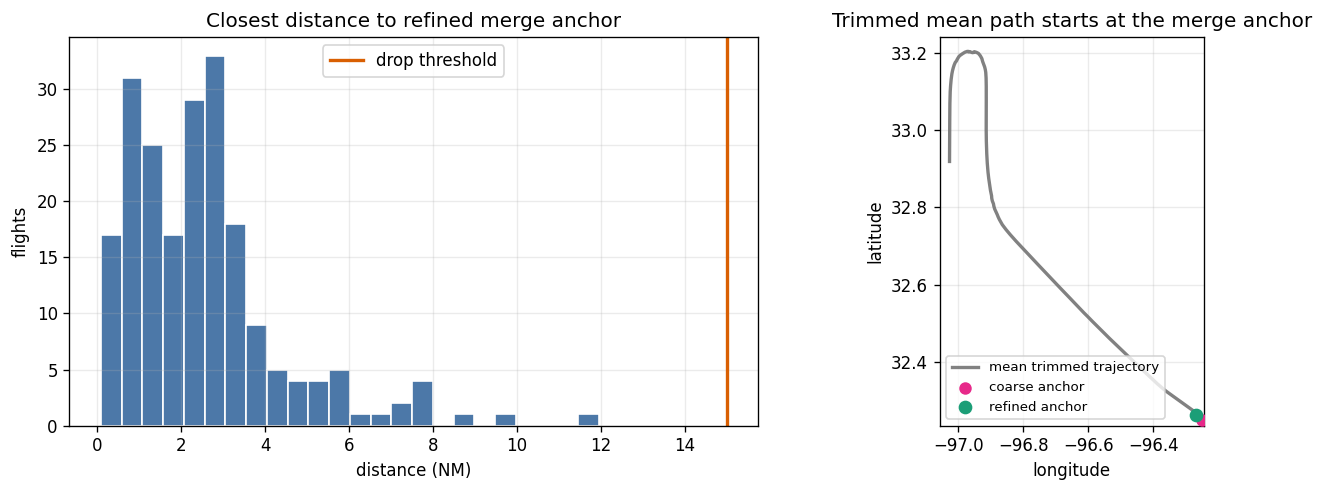

,event,start,end,length,peak_index,active_count,active_fraction,raw_gain,active_gain,score,explained_fraction,start_fraction,end_fraction,start_nm_from_merge,end_nm_from_merge
0,0,136,176,40,156,198,0.9519,1.435247e+11,1.436910e+11,1.434977e+11,0.6141,0.6834,0.8794,62.6108,77.7056
1,1,83,123,40,103,74,0.3558,1.534381e+10,1.500834e+10,1.509218e+10,0.0641,0.4171,0.6131,38.2524,56.3065
2,2,0,40,40,0,141,0.6779,6.764354e+10,6.752615e+10,6.752557e+10,0.2886,0.0000,0.1960,0.0000,17.8323
3,3,113,153,40,133,25,0.1202,2.362295e+09,2.547901e+09,2.138815e+09,0.0109,0.5678,0.7638,52.0671,69.5693
4,4,60,100,40,80,15,0.0721,1.076918e+09,8.321397e+08,8.519383e+08,0.0036,0.3015,0.4975,27.6989,45.6493
5,5,160,200,40,196,23,0.1106,1.603056e+09,1.549461e+09,1.489317e+09,0.0066,0.8040,1.0000,71.7112,89.0334


Findings: the refined merge anchor is lon/lat (-96.2667, 32.2644). The trim keeps 208 flights and drops 0 flights; median closest-anchor distance is 2.29 NM. On the merge-to-threshold segment, the model detects 6 windows and explains 98.6% of centered normal-residual energy. This removes the earlier uncontrolled upstream fanout from the analysis rather than merely hiding it in the plots.

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(kept_trim['min_anchor_distance_nm'], bins=24, color='#4c78a8', edgecolor='white')
axes[0].axvline(MAX_ANCHOR_DISTANCE_NM, color='#d95f02', linewidth=2, label='drop threshold')
axes[0].set_title('Closest distance to refined merge anchor')
axes[0].set_xlabel('distance (NM)')
axes[0].set_ylabel('flights')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.25)

plot_latlon_path(axes[1], mean_xy_m, color='#737373', linewidth=2.0, alpha=0.9, label='mean trimmed trajectory')
refined_anchor_lat = float(trim_info.get('refined_anchor_lat_deg', COARSE_MERGE_ANCHOR_LAT_DEG))
refined_anchor_lon = float(trim_info.get('refined_anchor_lon_deg', COARSE_MERGE_ANCHOR_LON_DEG))
axes[1].scatter([COARSE_MERGE_ANCHOR_LON_DEG], [COARSE_MERGE_ANCHOR_LAT_DEG], color='#e7298a', s=42, label='coarse anchor', zorder=5)
axes[1].scatter([refined_anchor_lon], [refined_anchor_lat], color='#1b9e77', s=52, label='refined anchor', zorder=6)
finish_geo_axes(axes[1], title='Trimmed mean path starts at the merge anchor')
axes[1].legend(loc='best', fontsize=8)
fig.tight_layout()
plt.show()

event_rows = pd.DataFrame(event_summary(result))
if not event_rows.empty:
    event_rows['start_fraction'] = event_rows['start'].map(lambda idx: station_fraction[int(idx)])
    event_rows['end_fraction'] = event_rows['end'].map(lambda idx: station_fraction[min(int(idx) - 1, len(station_fraction) - 1)])
    event_rows['start_nm_from_merge'] = event_rows['start'].map(lambda idx: station_distance_nm[int(idx)])
    event_rows['end_nm_from_merge'] = event_rows['end'].map(lambda idx: station_distance_nm[min(int(idx) - 1, len(station_distance_nm) - 1)])

display(event_rows.round(4))

if event_rows.empty:
    display(Markdown('No event windows were detected with the current fit settings.'))
else:
    display(
        Markdown(
            f'Findings: the refined merge anchor is lon/lat ({refined_anchor_lon:.4f}, {refined_anchor_lat:.4f}). '
            f'The trim keeps {len(matrix.flight_ids)} flights and drops {(trim_metadata["status"] == "dropped").sum()} flights; median closest-anchor distance is {kept_trim["min_anchor_distance_nm"].median():.2f} NM. '
            f'On the merge-to-threshold segment, the model detects {len(result.events)} windows and explains {result.explained_fraction:.1%} of centered normal-residual energy. '
            f'This removes the earlier uncontrolled upstream fanout from the analysis rather than merely hiding it in the plots.'
        )
    )

## Residual energy and model reconstruction

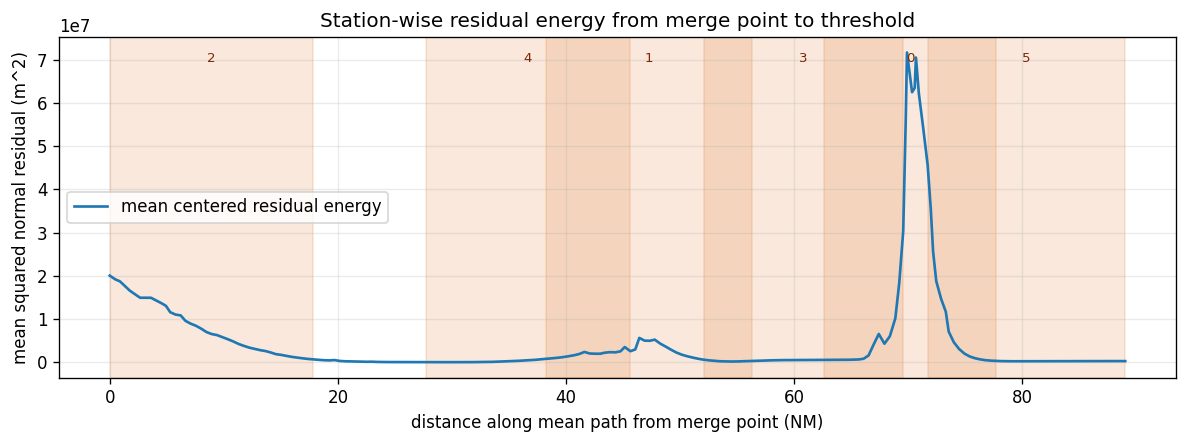

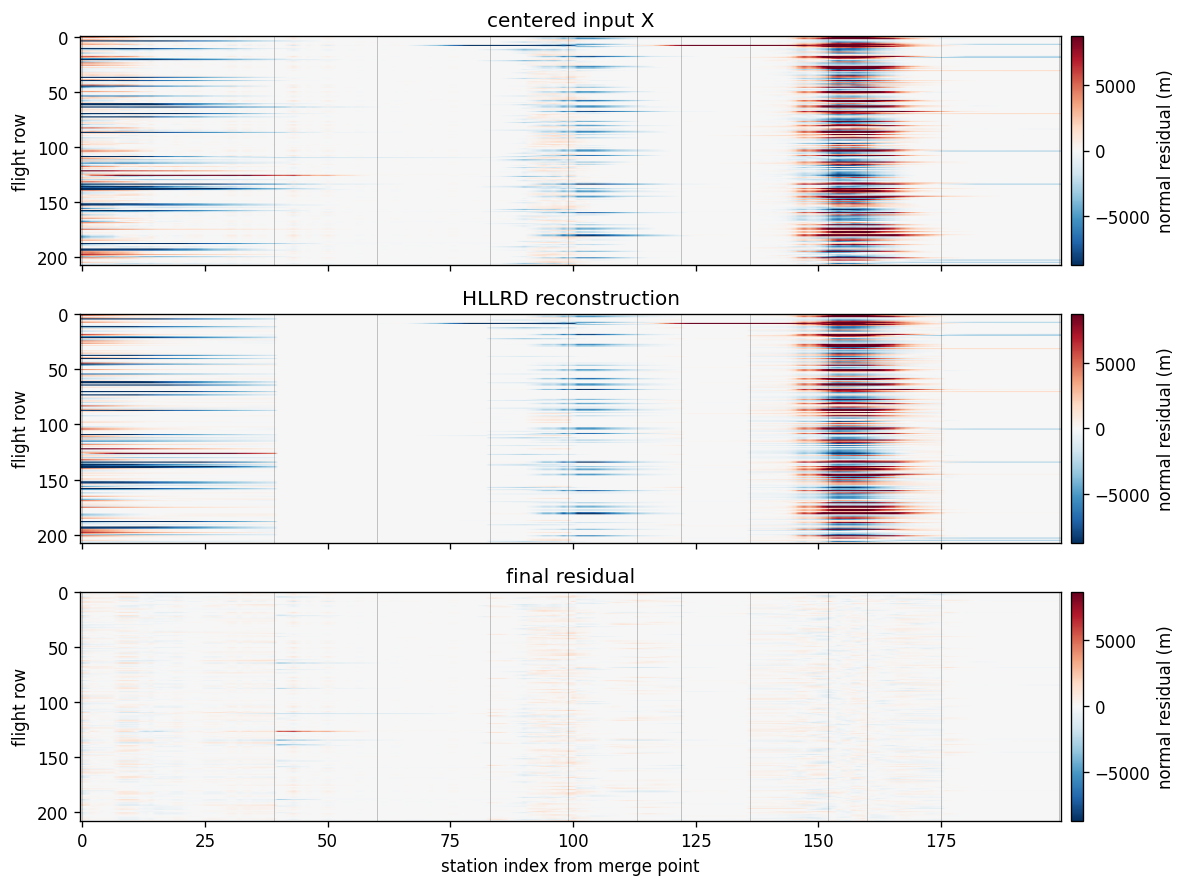

In [42]:
fig, ax = plt.subplots(figsize=(10, 3.8))
energy = np.mean(matrix.X_centered * matrix.X_centered, axis=0)
ax.plot(station_distance_nm, energy, color='#1f77b4', linewidth=1.6, label='mean centered residual energy')
for event_index, event in enumerate(result.events):
    ax.axvspan(station_distance_nm[event.start], station_distance_nm[event.end - 1], color='#d95f02', alpha=0.14)
    ax.text(
        0.5 * (station_distance_nm[event.start] + station_distance_nm[event.end - 1]),
        float(np.max(energy)) if energy.size else 0.0,
        str(event_index),
        ha='center',
        va='top',
        fontsize=8,
        color='#7f2704',
    )
ax.set_title('Station-wise residual energy from merge point to threshold')
ax.set_xlabel('distance along mean path from merge point (NM)')
ax.set_ylabel('mean squared normal residual (m^2)')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

heatmap_values = [
    (result.reconstruction + result.residual, 'centered input X'),
    (result.reconstruction, 'HLLRD reconstruction'),
    (result.residual, 'final residual'),
]
vmax = max(float(np.nanpercentile(np.abs(values), 98)) for values, _ in heatmap_values)
vmax = vmax if vmax > 0.0 else 1.0
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
for ax, (values, title) in zip(axes, heatmap_values, strict=True):
    image = ax.imshow(values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    for event in result.events:
        ax.axvline(event.start, color='black', linewidth=0.5, alpha=0.25)
        ax.axvline(event.end - 1, color='black', linewidth=0.5, alpha=0.25)
    ax.set_title(title)
    ax.set_ylabel('flight row')
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01, label='normal residual (m)')
axes[-1].set_xlabel('station index from merge point')
fig.tight_layout()
plt.show()

## Where the event windows sit on the map

Each panel shows the full trimmed mean trajectory in gray and one detected event interval as an orange segment.

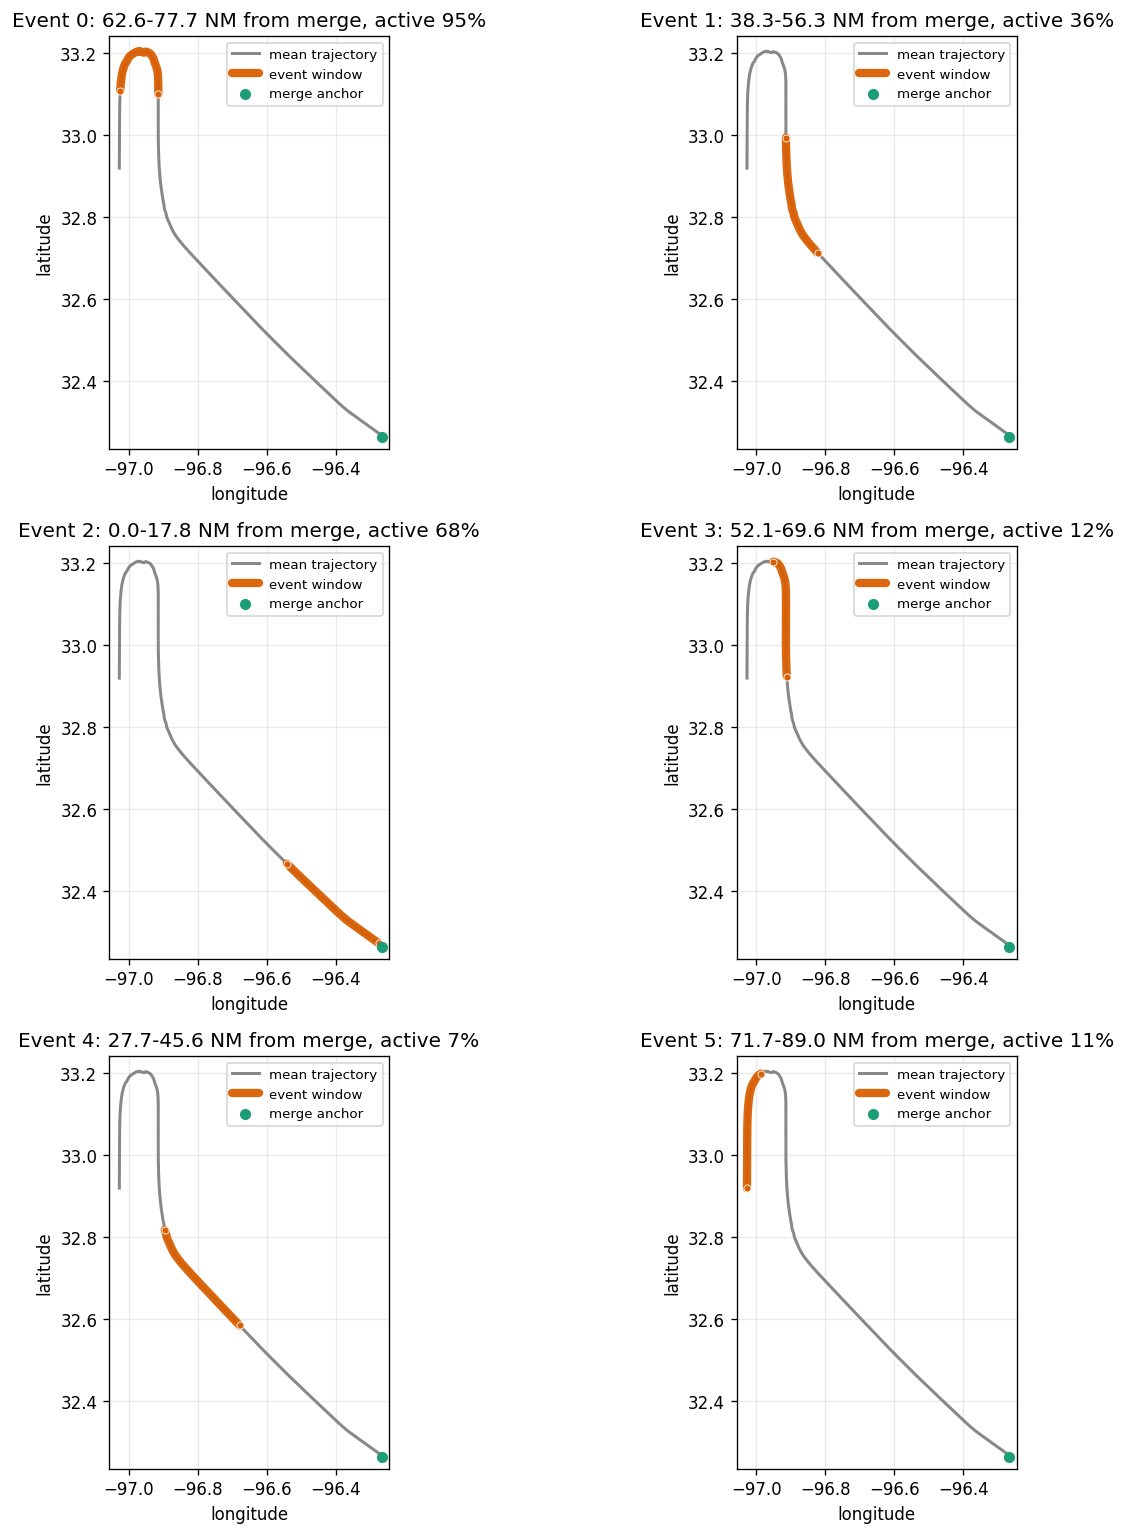

In [43]:
event_count = len(result.events)
cols = 2
rows = max(1, ceil(event_count / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4.3 * rows), squeeze=False)

for ax in axes.ravel():
    ax.axis('off')

for event_index, event in enumerate(result.events):
    ax = axes.ravel()[event_index]
    ax.axis('on')
    plot_latlon_path(ax, mean_xy_m, color='#737373', linewidth=1.8, alpha=0.85, label='mean trajectory')
    plot_event_segment(ax, event, mean_xy_m, color='#d95f02', linewidth=5.0, label='event window')
    ax.scatter([refined_anchor_lon], [refined_anchor_lat], color='#1b9e77', s=32, label='merge anchor', zorder=6)
    finish_geo_axes(
        ax,
        title=f'Event {event_index}: {station_distance_nm[event.start]:.1f}-{station_distance_nm[event.end - 1]:.1f} NM from merge, active {event.active_fraction:.0%}',
    )
    ax.legend(loc='best', fontsize=8)

fig.tight_layout()
plt.show()

## Event functionals V_k

`V_k` has two local basis functions per event. Component signs are arbitrary because they come from SVD; the shape and support are the important checks.

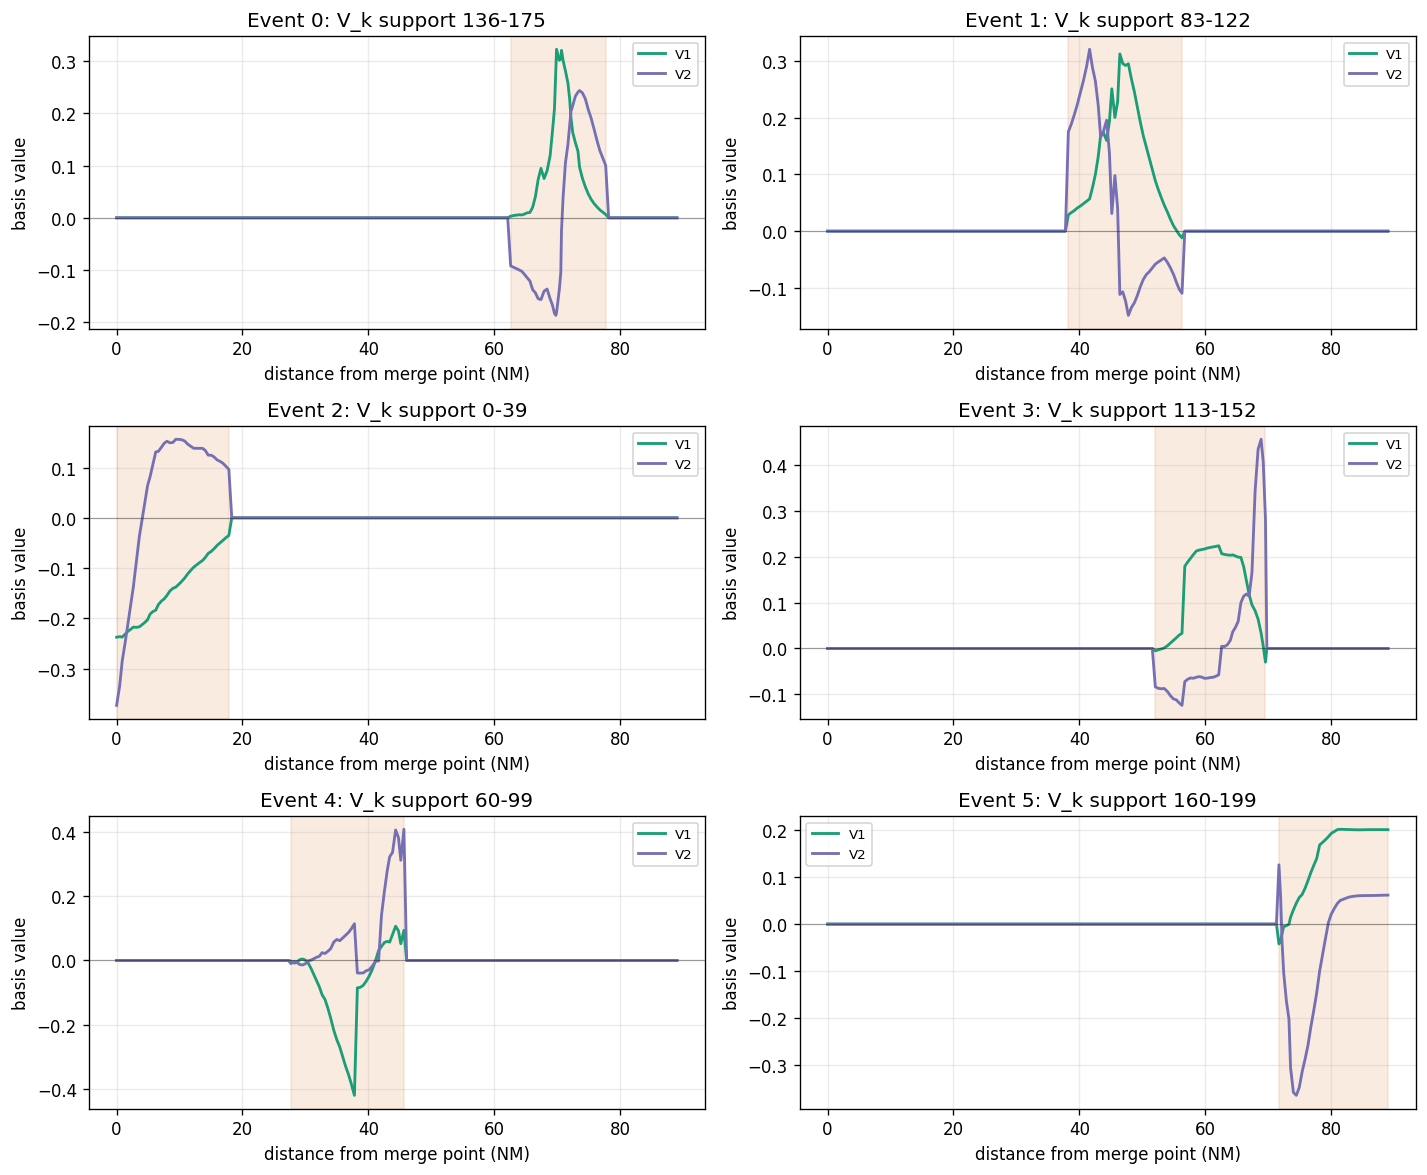

In [44]:
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.3 * rows), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')

for event_index, event in enumerate(result.events):
    ax = axes.ravel()[event_index]
    ax.axis('on')
    ax.axvspan(station_distance_nm[event.start], station_distance_nm[event.end - 1], color='#d95f02', alpha=0.12)
    ax.plot(station_distance_nm, event.basis[:, 0], color='#1b9e77', linewidth=1.7, label='V1')
    ax.plot(station_distance_nm, event.basis[:, 1], color='#7570b3', linewidth=1.7, label='V2')
    ax.axhline(0.0, color='black', linewidth=0.7, alpha=0.35)
    ax.set_title(f'Event {event_index}: V_k support {event.start}-{event.end - 1}')
    ax.set_xlabel('distance from merge point (NM)')
    ax.set_ylabel('basis value')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best', fontsize=8)

fig.tight_layout()
plt.show()

## Per-window Z_k scores versus five trajectories

For each event, the five flights are selected as quantiles of the first score coordinate among active flights. The full trimmed trajectories are colored, and the same event window is drawn thicker on each selected trajectory.

### Event 0: 62.6-77.7 NM from merge, active 198/208 (95.2%)

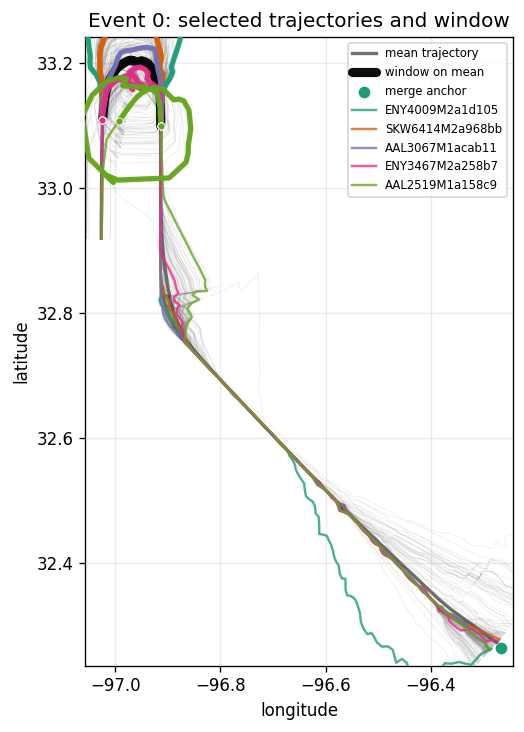

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,126,ENY4009M2a1d105,ENY4009M2,RW17L,-29953.29,4189.48,30244.85
1,#d95f02,190,SKW6414M2a968bb,SKW6414M2,RW18R,-13379.69,891.73,13409.37
2,#7570b3,93,AAL3067M1acab11,AAL3067M1,RW17L,1105.75,3651.21,3814.98
3,#e7298a,116,ENY3467M2a258b7,ENY3467M2,RW17L,23599.34,1771.19,23665.71
4,#66a61e,68,AAL2519M1a158c9,AAL2519M1,RW17L,77934.21,5641.51,78138.13


### Event 1: 38.3-56.3 NM from merge, active 74/208 (35.6%)

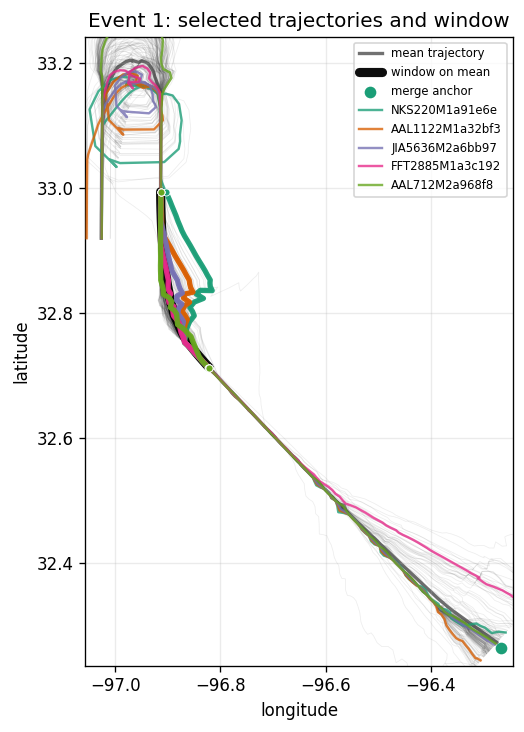

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,181,NKS220M1a91e6e,NKS220M1,RW18R,-28997.23,6166.49,29645.66
1,#d95f02,7,AAL1122M1a32bf3,AAL1122M1,RW17L,-14928.18,2459.21,15129.39
2,#7570b3,171,JIA5636M2a6bb97,JIA5636M2,RW17L,-8664.09,1300.15,8761.10
3,#e7298a,139,FFT2885M1a3c192,FFT2885M1,RW17L,-3232.73,617.85,3291.24
4,#66a61e,106,AAL712M2a968f8,AAL712M2,RW17L,-1029.56,-2339.85,2556.34


### Event 2: 0.0-17.8 NM from merge, active 141/208 (67.8%)

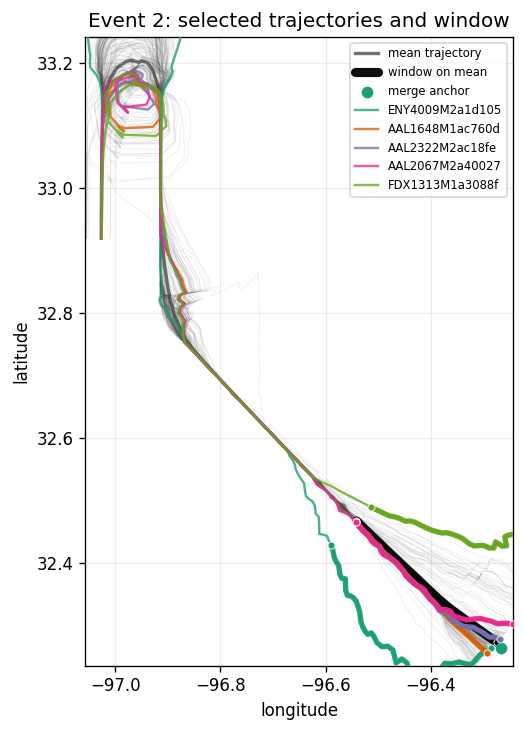

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,126,ENY4009M2a1d105,ENY4009M2,RW17L,-54787.50,31025.01,62962.07
1,#d95f02,28,AAL1648M1ac760d,AAL1648M1,RW17L,-3556.96,-2298.92,4235.21
2,#7570b3,59,AAL2322M2ac18fe,AAL2322M2,RW17L,957.86,2512.19,2688.61
3,#e7298a,46,AAL2067M2a40027,AAL2067M2,RW18R,6767.15,7461.63,10073.25
4,#66a61e,138,FDX1313M1a3088f,FDX1313M1,RW18R,84391.26,-460.59,84392.51


### Event 3: 52.1-69.6 NM from merge, active 25/208 (12.0%)

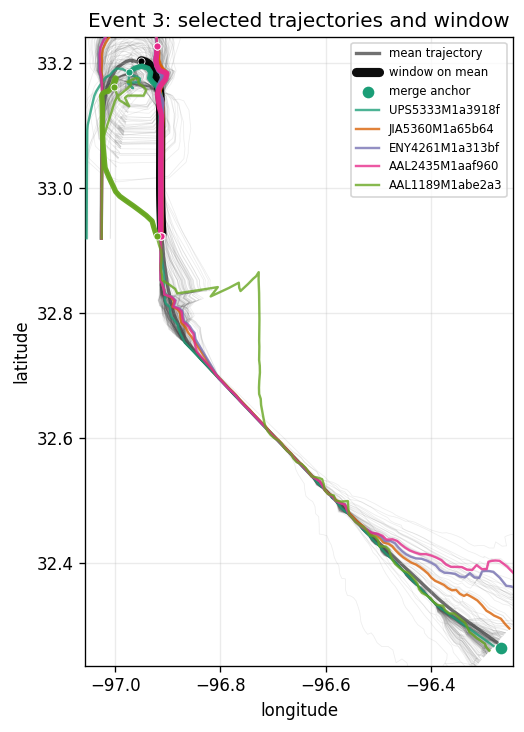

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,203,UPS5333M1a3918f,UPS5333M1,RW17C,-1628.95,-2363.11,2870.15
1,#d95f02,159,JIA5360M1a65b64,JIA5360M1,RW18R,536.56,2252.49,2315.51
2,#7570b3,136,ENY4261M1a313bf,ENY4261M1,RW18R,984.39,3321.78,3464.57
3,#e7298a,62,AAL2435M1aaf960,AAL2435M1,RW17L,1279.14,2934.22,3200.91
4,#66a61e,8,AAL1189M1abe2a3,AAL1189M1,RW17L,47944.70,3446.54,48068.42


### Event 4: 27.7-45.6 NM from merge, active 15/208 (7.2%)

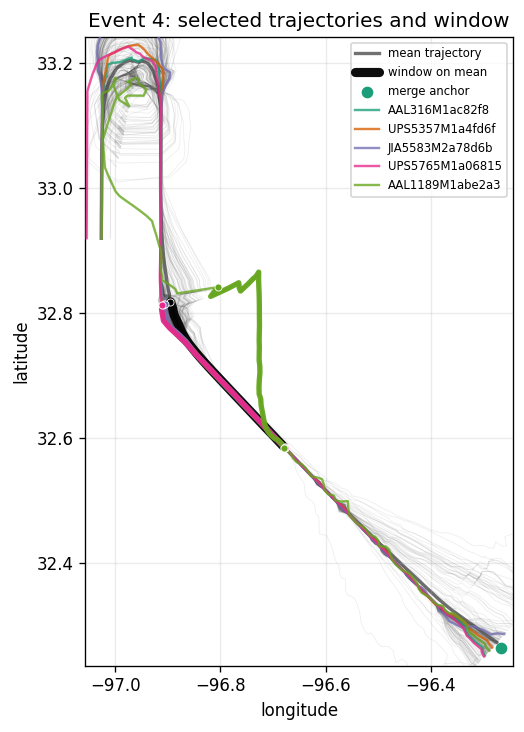

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,98,AAL316M1ac82f8,AAL316M1,RW17L,472.82,2720.25,2761.03
1,#d95f02,204,UPS5357M1a4fd6f,UPS5357M1,RW17L,571.32,2356.97,2425.22
2,#7570b3,167,JIA5583M2a78d6b,JIA5583M2,RW17L,637.08,2243.45,2332.16
3,#e7298a,205,UPS5765M1a06815,UPS5765M1,RW18R,715.80,2902.19,2989.16
4,#66a61e,8,AAL1189M1abe2a3,AAL1189M1,RW17L,26991.03,-2482.95,27104.99


### Event 5: 71.7-89.0 NM from merge, active 23/208 (11.1%)

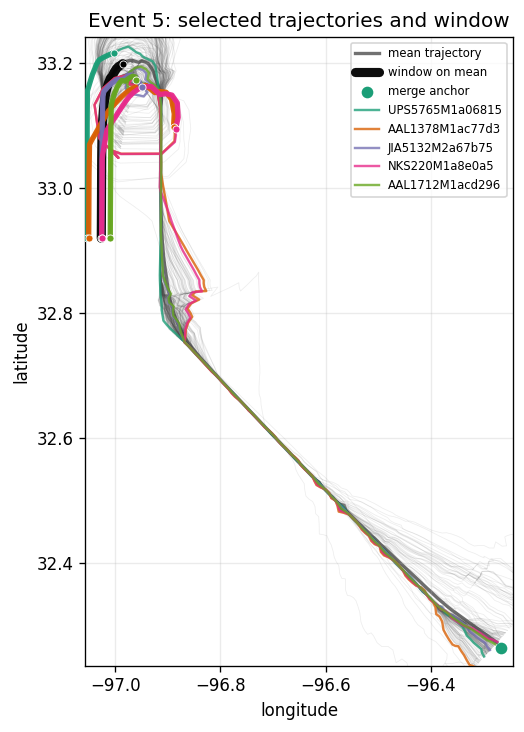

,color,flight_row,flight_id,callsign,runway,Z1,Z2,|Z|
0,#1b9e77,205,UPS5765M1a06815,UPS5765M1,RW18R,-13955.39,2085.42,14110.35
1,#d95f02,18,AAL1378M1ac77d3,AAL1378M1,RW17C,-9918.91,-4182.90,10764.83
2,#7570b3,148,JIA5132M2a67b75,JIA5132M2,RW18R,-520.00,2708.97,2758.43
3,#e7298a,180,NKS220M1a8e0a5,NKS220M1,RW18R,1624.62,-3708.49,4048.74
4,#66a61e,31,AAL1712M1acd296,AAL1712M1,RW17L,7909.18,-991.61,7971.10


In [45]:
TRAJECTORY_COLORS = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']


def select_five_flights(event: object) -> list[int]:
    active = np.flatnonzero(event.active_mask)
    if active.size == 0:
        return []
    ordered = active[np.argsort(event.coefficients[active, 0])]
    if ordered.size <= 5:
        return [int(item) for item in ordered]
    positions = np.rint(np.linspace(0, ordered.size - 1, 5)).astype(int)
    chosen: list[int] = []
    for item in ordered[positions]:
        value = int(item)
        if value not in chosen:
            chosen.append(value)
    if len(chosen) < 5:
        for item in ordered:
            value = int(item)
            if value not in chosen:
                chosen.append(value)
            if len(chosen) == 5:
                break
    return chosen


def z_score_table(event_index: int, flight_rows: list[int]) -> pd.DataFrame:
    event = result.events[event_index]
    rows = []
    for color, row_index in zip(TRAJECTORY_COLORS, flight_rows, strict=False):
        flight_id = matrix.flight_ids[row_index]
        meta = flight_metadata.get(flight_id)
        z1, z2 = event.coefficients[row_index]
        rows.append(
            {
                'color': color,
                'flight_row': row_index,
                'flight_id': flight_id,
                'callsign': meta.callsign if meta else '',
                'runway': meta.runway if meta else '',
                'Z1': z1,
                'Z2': z2,
                '|Z|': float(np.hypot(z1, z2)),
            }
        )
    return pd.DataFrame(rows)


def plot_event_trajectory_examples(event_index: int, flight_rows: list[int]) -> None:
    event = result.events[event_index]
    fig, ax = plt.subplots(figsize=(7.5, 6.2))
    plot_latlon_path(ax, mean_xy_m, color='#4d4d4d', linewidth=2.0, alpha=0.8, label='mean trajectory', zorder=1)
    for row_index in range(len(matrix.flight_ids)):
        xy_m = flight_xy_m(row_index)
        plot_latlon_path(ax, xy_m, color='#4d4d4d', linewidth=0.45, alpha=0.1, label=None, zorder=2)
    plot_event_segment(ax, event, mean_xy_m, color='black', linewidth=5.5, label='window on mean', zorder=3)
    ax.scatter([refined_anchor_lon], [refined_anchor_lat], color='#1b9e77', s=36, label='merge anchor', zorder=6)
    for color, row_index in zip(TRAJECTORY_COLORS, flight_rows, strict=False):
        xy_m = flight_xy_m(row_index)
        flight_id = matrix.flight_ids[row_index]
        plot_latlon_path(ax, xy_m, color=color, linewidth=1.45, alpha=0.78, label=flight_id, zorder=4)
        plot_event_segment(ax, event, xy_m, color=color, linewidth=3.2, label=None, zorder=5)
    finish_geo_axes(ax, title=f'Event {event_index}: selected trajectories and window')
    ax.legend(loc='best', fontsize=7)
    fig.tight_layout()
    plt.show()


for event_index, event in enumerate(result.events):
    selected_rows = select_five_flights(event)
    display(
        Markdown(
            f'### Event {event_index}: {station_distance_nm[event.start]:.1f}-{station_distance_nm[event.end - 1]:.1f} NM from merge, '
            f'active {event.active_count}/{len(matrix.flight_ids)} ({event.active_fraction:.1%})'
        )
    )
    plot_event_trajectory_examples(event_index, selected_rows)
    display(z_score_table(event_index, selected_rows).round({'Z1': 2, 'Z2': 2, '|Z|': 2}))

## Event response to interpolated Z scores

Each panel keeps only one event active and draws five synthetic trajectories from the smallest observed active `(Z1, Z2)` pair to the largest observed active `(Z1, Z2)` pair for that event.

### Event 0: Z sweep from componentwise active minimum to componentwise active maximum

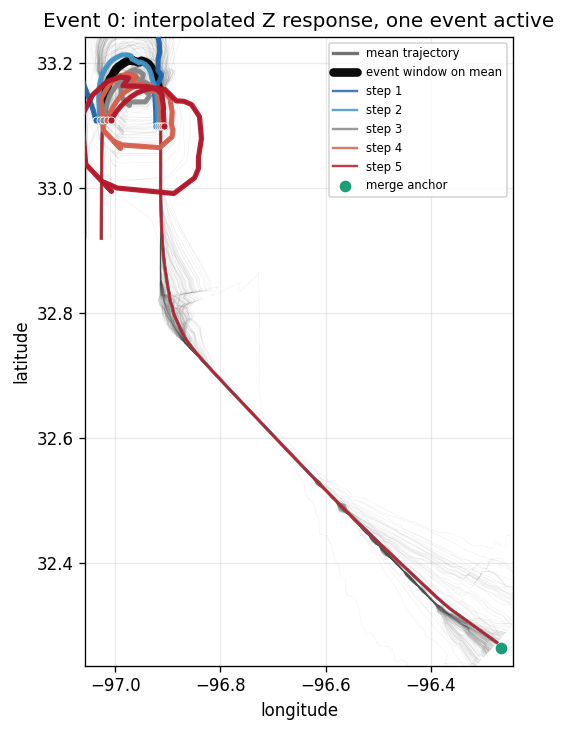

,step,color,Z1,Z2,|Z|
0,1,#2166ac,-29953.29,-10292.04,31672.16
1,2,#4393c3,-2981.41,-5364.44,6137.27
2,3,#878787,23990.46,-436.84,23994.44
3,4,#d6604d,50962.33,4490.76,51159.81
4,5,#b2182b,77934.21,9418.36,78501.25


### Event 1: Z sweep from componentwise active minimum to componentwise active maximum

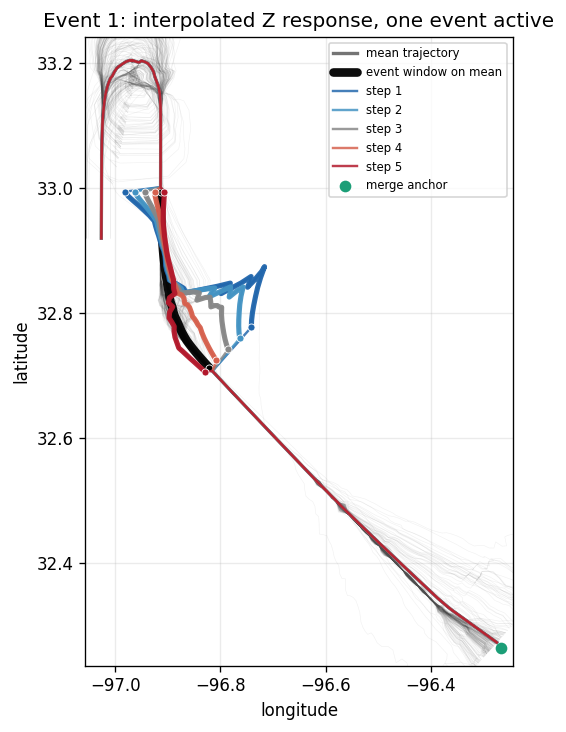

,step,color,Z1,Z2,|Z|
0,1,#2166ac,-28997.23,-54371.36,61620.49
1,2,#4393c3,-22005.31,-39236.90,44986.31
2,3,#878787,-15013.39,-24102.44,28395.94
3,4,#d6604d,-8021.48,-8967.97,12031.98
4,5,#b2182b,-1029.56,6166.49,6251.85


### Event 2: Z sweep from componentwise active minimum to componentwise active maximum

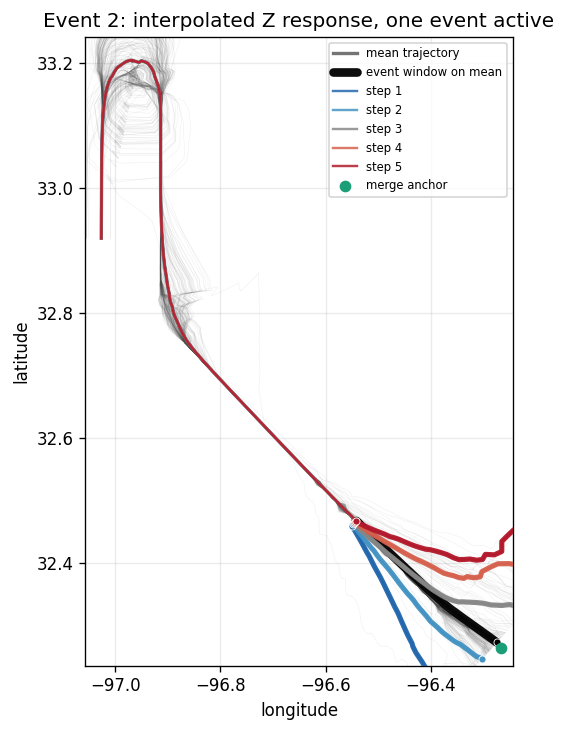

,step,color,Z1,Z2,|Z|
0,1,#2166ac,-54787.50,-7630.50,55316.32
1,2,#4393c3,-19992.81,2033.37,20095.95
2,3,#878787,14801.88,11697.25,18865.88
3,4,#d6604d,49596.57,21361.13,54001.09
4,5,#b2182b,84391.26,31025.01,89913.49


### Event 3: Z sweep from componentwise active minimum to componentwise active maximum

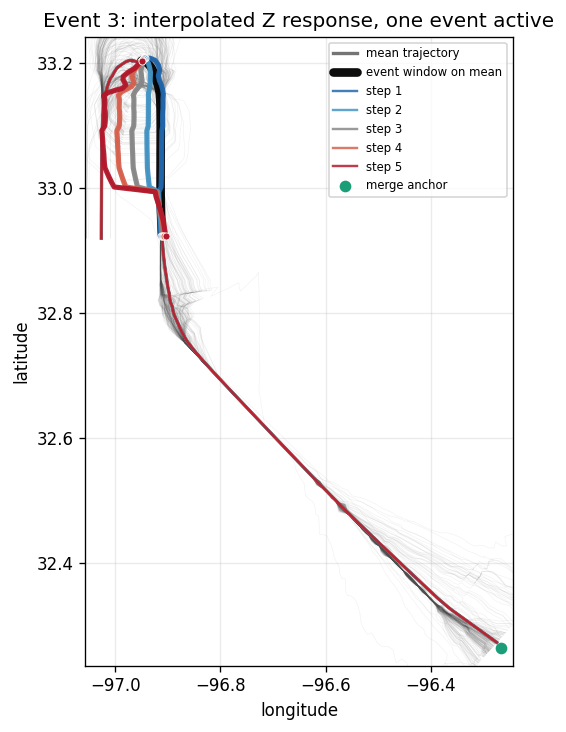

,step,color,Z1,Z2,|Z|
0,1,#2166ac,-1628.95,-2891.54,3318.81
1,2,#4393c3,10764.46,-962.51,10807.41
2,3,#878787,23157.88,966.53,23178.04
3,4,#d6604d,35551.29,2895.57,35669.01
4,5,#b2182b,47944.70,4824.60,48186.84


### Event 4: Z sweep from componentwise active minimum to componentwise active maximum

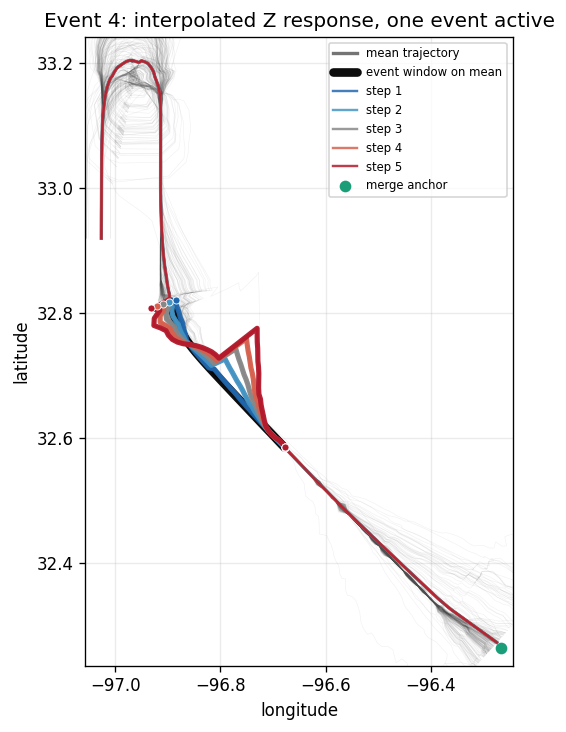

,step,color,Z1,Z2,|Z|
0,1,#2166ac,472.82,-2482.95,2527.57
1,2,#4393c3,7102.37,-1136.67,7192.75
2,3,#878787,13731.92,209.62,13733.52
3,4,#d6604d,20361.48,1555.90,20420.84
4,5,#b2182b,26991.03,2902.19,27146.61


### Event 5: Z sweep from componentwise active minimum to componentwise active maximum

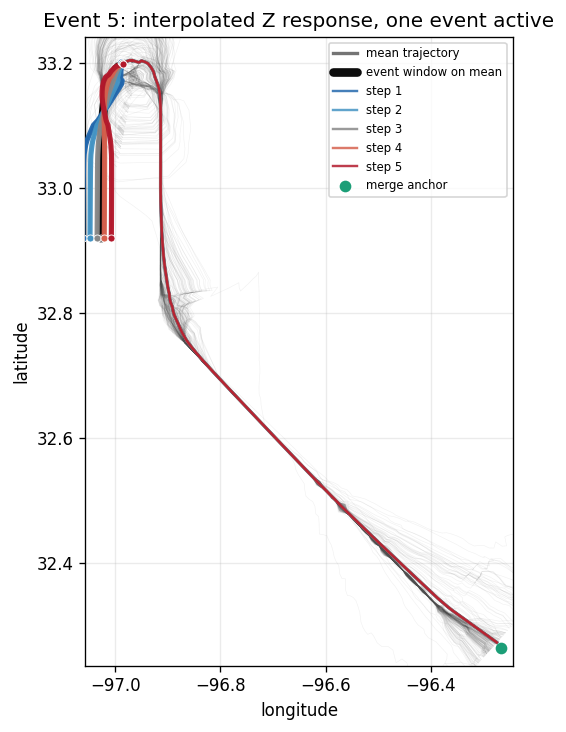

,step,color,Z1,Z2,|Z|
0,1,#2166ac,-13955.39,-7602.13,15891.67
1,2,#4393c3,-8489.25,-4873.27,9788.57
2,3,#878787,-3023.11,-2144.41,3706.43
3,4,#d6604d,2443.04,584.45,2511.97
4,5,#b2182b,7909.18,3313.31,8575.15


In [46]:
Z_SWEEP_COLORS = ['#2166ac', '#4393c3', '#878787', '#d6604d', '#b2182b']


def event_z_sweep(event: object, steps: int = 5) -> np.ndarray:
    active = np.flatnonzero(event.active_mask)
    coefficients = event.coefficients[active] if active.size else event.coefficients
    if coefficients.size == 0:
        return np.zeros((0, 2), dtype=float)
    z_min = np.min(coefficients, axis=0)
    z_max = np.max(coefficients, axis=0)
    weights = np.linspace(0.0, 1.0, steps)
    return z_min[None, :] + weights[:, None] * (z_max - z_min)[None, :]


def event_response_xy(event: object, z: np.ndarray) -> np.ndarray:
    normal_offset_m = event.basis @ z
    return mean_xy_m + normal_offset_m[:, None] * matrix.normals_xy


def z_sweep_table(event_index: int, z_values: np.ndarray) -> pd.DataFrame:
    rows = []
    for step_index, (color, z) in enumerate(zip(Z_SWEEP_COLORS, z_values, strict=False), start=1):
        rows.append(
            {
                'step': step_index,
                'color': color,
                'Z1': float(z[0]),
                'Z2': float(z[1]),
                '|Z|': float(np.hypot(z[0], z[1])),
            }
        )
    return pd.DataFrame(rows)


def plot_event_z_sweep(event_index: int) -> pd.DataFrame:
    event = result.events[event_index]
    z_values = event_z_sweep(event, steps=5)
    fig, ax = plt.subplots(figsize=(7.8, 6.2))
    plot_latlon_path(ax, mean_xy_m, color='#4d4d4d', linewidth=2.0, alpha=0.78, label='mean trajectory', zorder=1)
    for row_index in range(len(matrix.flight_ids)):
        plot_latlon_path(ax, flight_xy_m(row_index), color='#4d4d4d', linewidth=0.35, alpha=0.08, label=None, zorder=2)
    plot_event_segment(ax, event, mean_xy_m, color='black', linewidth=5.2, label='event window on mean', zorder=3)
    for step_index, (color, z) in enumerate(zip(Z_SWEEP_COLORS, z_values, strict=False), start=1):
        xy_m = event_response_xy(event, z)
        label = f'step {step_index}'
        plot_latlon_path(ax, xy_m, color=color, linewidth=1.45, alpha=0.84, label=label, zorder=4)
        plot_event_segment(ax, event, xy_m, color=color, linewidth=3.1, label=None, zorder=5)
    ax.scatter([refined_anchor_lon], [refined_anchor_lat], color='#1b9e77', s=36, label='merge anchor', zorder=6)
    finish_geo_axes(
        ax,
        title=f'Event {event_index}: interpolated Z response, one event active',
    )
    ax.legend(loc='best', fontsize=7)
    fig.tight_layout()
    plt.show()
    return z_sweep_table(event_index, z_values)


for event_index, event in enumerate(result.events):
    display(
        Markdown(
            f'### Event {event_index}: Z sweep from componentwise active minimum to componentwise active maximum'
        )
    )
    display(plot_event_z_sweep(event_index).round({'Z1': 2, 'Z2': 2, '|Z|': 2}))